In [70]:
import os
import h5py
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import butter, filtfilt, resample_poly, resample, find_peaks
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns
from scipy.stats import wilcoxon
import scipy

# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [81]:
# ── paths ──────────────────────────────────────────────────────────────
h5_dir   = r"C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_hc\h5_outputs"
boris_dir = r"C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\BLA_ChR_resp_pilot1 (SS)\BLA_resp_ChR_cm_boris"
# ── pick one file of each to inspect ───────────────────────────────────
h5_files    = [f for f in os.listdir(h5_dir)    if f.endswith('.h5')]
boris_files = [f for f in os.listdir(boris_dir) if f.endswith('.csv')]

print("H5 files found:")
for i, f in enumerate(h5_files):
    print(f"  [{i}] {f}")

print("\nBORIS files found:")
for i, f in enumerate(boris_files):
    print(f"  [{i}] {f}")

# ── inspect the first H5 ────────────────────────────────────────────────
h5_path = os.path.join(h5_dir, h5_files[0])
print(f"\n--- Inspecting H5: {h5_files[0]} ---")

with h5py.File(h5_path, 'r') as f:
    print("Root attrs:", dict(f.attrs))
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  DATASET '{name}': shape={obj.shape}, dtype={obj.dtype}, attrs={dict(obj.attrs)}")
            if obj.shape[0] < 20:
                print(f"    values: {obj[:]}")
            else:
                print(f"    first 5: {obj[:5]}")
                print(f"    last  5: {obj[-5:]}")
        elif isinstance(obj, h5py.Group):
            print(f"  GROUP   '{name}': attrs={dict(obj.attrs)}")
    f.visititems(show)

# ── inspect the first BORIS CSV ─────────────────────────────────────────
boris_path = os.path.join(boris_dir, boris_files[0])
print(f"\n--- Inspecting BORIS: {boris_files[0]} ---")

df = pd.read_csv(boris_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df[['Subject','Behavior','Start (s)','Stop (s)','Image index start','Image index stop']].head(10).to_string())

H5 files found:
  [0] 1_1_i_cm_1_2_d_20260106_134350.h5
  [1] 1_1_i_cm_1_3_s_20260107_163611.h5
  [2] 1_2_d_cm_1_3_s_20260108_114416.h5
  [3] 1_3_s_1_2_d_20260107_165340.h5
  [4] 1_3_s_cm_1_1_i_20260106_122823.h5
  [5] 2_1_d_cm_2.3_i_20260106_105109.h5
  [6] 2_1_d_cm_2_2_s_20260108_112426.h5
  [7] 2_2_s_cm_2_1_d_20260108_120453.h5
  [8] 2_2_s_cm_2_1_d_20260108_120453.rec.h5
  [9] 2_2_s_cm_2_3_i_20260106_132549.h5
  [10] 3_1_i_cm_3_2_d_20260106_115157.h5
  [11] 3_1_i_cm_3_3_s_20260107_123230.h5
  [12] 3_2_d_cm_3_3_s_20260107_140924.h5
  [13] 3_3_s_cm_3_1_i_20260106_124546.h5
  [14] 3_3_s_cm_3_2_d_20260107_171330.h5
  [15] 4_1_s_cm_4_2_d_20260107_160439.h5
  [16] 4_2_d_cm_4_1_s_20260107_150836.h5
  [17] 4_3_d_cm_4_1_s_20260107_113120.h5
  [18] 5_1_i_cm_5_2_d_20260106_120946.h5
  [19] 5_1_i_cm_5_3_s_20260107_132309.h5
  [20] 6_2_d_cm_6_3_s_20260107_154939.h5
  [21] 7_1_d_cm_7_2_s_20260106_111330.h5
  [22] 7_2_s_cm_7_1_d_20260106_130431.h5
  [23] 8_1_s_cm_8_2_d_20260107_152812.h5
  [24] 8_

In [73]:
# ======================================================
# COMPARE H5 AND BORIS FILENAMES
# ======================================================

print(f"H5 files: {len(h5_files)}")
print(f"BORIS files: {len(boris_files)}")

# remove duplicate .rec.h5 file
h5_clean = [
    f for f in h5_files
    if not f.endswith(".rec.h5")
]

print(f"H5 after removing .rec.h5: {len(h5_clean)}")

H5 files: 25
BORIS files: 32
H5 after removing .rec.h5: 24


In [83]:
# ======================================================
# CREATE ONE BORIS DATAFRAME PER RECORDING
# ======================================================

recording_dict = {}

# ------------------------------------------------------
# create standardized recording key
# ------------------------------------------------------

def make_key(filename):

    stem = filename.replace(".csv", "")

    parts = stem.split("_")

    # --------------------------------------------------
    # VIJAY CM
    #
    # 1_1_2_i_cm_1_3_s_20260107_163611.1_VT_CM.csv
    # --------------------------------------------------

    if "_VT_CM" in filename:

        return (
            f"{parts[0]}_{parts[1]}_"
            f"{parts[3]}_cm_"
            f"{parts[5]}_{parts[6]}_"
            f"{parts[7]}_"
            f"{parts[8]}_{parts[9].split('.')[0]}"
        )

    # --------------------------------------------------
    # VIJAY SA
    #
    # 1_1_i_cm_1_3_s_20260107_163611.1_VT_SA.csv
    # --------------------------------------------------

    elif "_VT_SA" in filename:

        return (
            f"{parts[0]}_{parts[1]}_"
            f"{parts[2]}_cm_"
            f"{parts[4]}_{parts[5]}_"
            f"{parts[6]}_"
            f"{parts[7]}_{parts[8].split('.')[0]}"
        )

    # --------------------------------------------------
    # SIMONE / BORIS_SS / AJ
    #
    # Handles BOTH:
    #
    # 1_1_2_i_cm_1_2_d_...
    # 1_3_2_s_1_2_d_...
    #
    # If cm is missing, add it.
    # --------------------------------------------------

    else:

        if "cm" in parts:

            cm_idx = parts.index("cm")

            return (
                f"{parts[0]}_{parts[1]}_"
                f"{parts[3]}_cm_"
                f"{parts[cm_idx+1]}_{parts[cm_idx+2]}_"
                f"{parts[cm_idx+3]}_"
                f"{parts[cm_idx+4]}_{parts[cm_idx+5].split('.')[0]}"
            )

        else:

            # AJ file missing "cm"
            return (
                f"{parts[0]}_{parts[1]}_"
                f"{parts[3]}_cm_"
                f"{parts[4]}_{parts[5]}_"
                f"{parts[6]}_"
                f"{parts[7]}_{parts[8].split('.')[0]}"
            )

# ------------------------------------------------------
# LOAD ALL BORIS FILES
# ------------------------------------------------------

for filename in boris_files:

    filepath = os.path.join(
        boris_dir,
        filename
    )

    key = make_key(filename)

    df = pd.read_csv(filepath)

    if key not in recording_dict:

        recording_dict[key] = df

    else:

        # merge VT_CM + VT_SA
        recording_dict[key] = pd.concat(
            [
                recording_dict[key],
                df
            ],
            ignore_index=True
        )

# ------------------------------------------------------
# SUMMARY
# ------------------------------------------------------

print(
    f"Unique recordings: {len(recording_dict)}"
)

print("\nExample keys:\n")

for key in sorted(recording_dict.keys())[:10]:

    print(key)

print("\nKeys missing cm:")

for key in sorted(recording_dict.keys()):

    if "_cm_" not in key:

        print(key)

Unique recordings: 25

Example keys:

1_1_i_cm_1_2_d_20260106_134350
1_1_i_cm_1_3_s_20260107_163611
1_2_d_cm_1_3_s_20260108_114416
1_3_s_cm_1_1_i_20260106_122823
1_3_s_cm_1_2_d_20260107_165340
2_1_d_cm_2_2_s_20260108_112426
2_1_d_cm_2_3_i_20260106_105109
2_2_s_cm_2_1_d_20260108_120453
2_2_s_cm_2_3_i_20260106_132549
3_1_i_cm_3_2_d_20260106_115157

Keys missing cm:


In [84]:
# ======================================================
# CREATE RECORDING METADATA DATAFRAME
# ======================================================

rank_order = {
    "s": "SUB",
    "i": "INT",
    "d": "DOM"
}

meta_rows = []

for key in recording_dict.keys():

    parts = key.split("_")

    row = {

        # recording id
        "RecordingKey": key,

        # IDs
        "SubjectID":
            f"{parts[0]}_{parts[1]}",

        "SocialAgentID":
            f"{parts[4]}_{parts[5]}",

        # ranks
        "SubjectRank":
            rank_order[parts[2]],

        "SocialAgentRank":
            rank_order[parts[6]]
    }

    # ------------------------------------------
    # relative interaction
    # ------------------------------------------

    rank_value = {
        "SUB": 0,
        "INT": 1,
        "DOM": 2
    }

    if (
        rank_value[row["SubjectRank"]]
        >
        rank_value[row["SocialAgentRank"]]
    ):

        row["RelativeInteraction"] = "DOM"

    elif (
        rank_value[row["SubjectRank"]]
        <
        rank_value[row["SocialAgentRank"]]
    ):

        row["RelativeInteraction"] = "SUB"

    else:

        row["RelativeInteraction"] = "EQUAL"

    meta_rows.append(row)

recording_meta = pd.DataFrame(meta_rows)

display(recording_meta)

print(recording_meta.shape)

,RecordingKey,SubjectID,SocialAgentID,SubjectRank,SocialAgentRank,RelativeInteraction
0,1_1_i_cm_1_2_d_20260106_134350,1_1,1_2,INT,DOM,SUB
1,1_1_i_cm_1_3_s_20260107_163611,1_1,1_3,INT,SUB,DOM
2,1_2_d_cm_1_3_s_20260108_114416,1_2,1_3,DOM,SUB,DOM
3,1_3_s_cm_1_2_d_20260107_165340,1_3,1_2,SUB,DOM,SUB
4,1_3_s_cm_1_1_i_20260106_122823,1_3,1_1,SUB,INT,SUB
5,2_1_d_cm_2_2_s_20260108_112426,2_1,2_2,DOM,SUB,DOM
6,2_1_d_cm_2_3_i_20260106_105109,2_1,2_3,DOM,INT,DOM
7,2_2_s_cm_2_1_d_20260108_120453,2_2,2_1,SUB,DOM,SUB
8,2_2_s_cm_2_3_i_20260106_132549,2_2,2_3,SUB,INT,SUB
9,3_1_i_cm_3_2_d_20260106_115157,3_1,3_2,INT,DOM,SUB


(25, 6)


In [85]:
print(
    recording_meta["RelativeInteraction"]
    .value_counts()
)

print(
    recording_meta["SubjectRank"]
    .value_counts()
)

print(
    recording_meta[
        [
            "SubjectID",
            "SubjectRank",
            "SocialAgentRank",
            "RelativeInteraction"
        ]
    ]
)

RelativeInteraction
SUB    13
DOM    12
Name: count, dtype: int64
SubjectRank
SUB    10
DOM     9
INT     6
Name: count, dtype: int64
   SubjectID SubjectRank SocialAgentRank RelativeInteraction
0        1_1         INT             DOM                 SUB
1        1_1         INT             SUB                 DOM
2        1_2         DOM             SUB                 DOM
3        1_3         SUB             DOM                 SUB
4        1_3         SUB             INT                 SUB
5        2_1         DOM             SUB                 DOM
6        2_1         DOM             INT                 DOM
7        2_2         SUB             DOM                 SUB
8        2_2         SUB             INT                 SUB
9        3_1         INT             DOM                 SUB
10       3_1         INT             SUB                 DOM
11       3_2         DOM             SUB                 DOM
12       3_3         SUB             INT                 SUB
13       3_3

In [86]:
# ======================================================
# CREATE MASTER BEHAVIOR DATAFRAME
# ======================================================

master_dfs = []

for key, df in recording_dict.items():

    temp = df.copy()

    meta = recording_meta[
        recording_meta["RecordingKey"] == key
    ].iloc[0]

    temp["RecordingKey"] = key

    temp["SubjectID"] = meta["SubjectID"]

    temp["SocialAgentID"] = meta["SocialAgentID"]

    temp["SubjectRank"] = meta["SubjectRank"]

    temp["SocialAgentRank"] = meta["SocialAgentRank"]

    temp["RelativeInteraction"] = (
        meta["RelativeInteraction"]
    )

    temp["InteractionDuration"] = (
        temp["Stop (s)"]
        -
        temp["Start (s)"]
    )

    master_dfs.append(temp)

master_df = pd.concat(
    master_dfs,
    ignore_index=True
)

print(master_df.shape)

display(
    master_df[
        [
            "Subject",
            "Behavior",
            "InteractionDuration",
            "SubjectID",
            "RelativeInteraction"
        ]
    ].head()
)

(3336, 35)


,Subject,Behavior,InteractionDuration,SubjectID,RelativeInteraction
0,social_agent,body sniffing,1.666,1_1,SUB
1,social_agent,body sniffing,1.067,1_1,SUB
2,social_agent,body sniffing,0.734,1_1,SUB
3,social_agent,facial sniffing,1.200,1_1,SUB
4,subject,facial sniffing,1.266,1_1,SUB


In [87]:
print(
    master_df["Behavior"]
    .value_counts()
)

print(
    master_df["Subject"]
    .value_counts()
)

print(
    master_df["RelativeInteraction"]
    .value_counts()
)

Behavior
digging                1342
facial sniffing        1234
body sniffing           392
anogenital sniffing     287
self-grooming            80
allogrooming              1
Name: count, dtype: int64
Subject
social_agent    1982
subject         1354
Name: count, dtype: int64
RelativeInteraction
SUB    1688
DOM    1648
Name: count, dtype: int64


In [88]:
# ======================================================
# CREATE DATAFRAME FOR SUBJECT-INITIATED SOCIAL INVESTIGATION
# ======================================================

plot_df = (

    # ------------------------------------------
    # Start with the full event-level dataframe
    # ------------------------------------------
    master_df

    # ------------------------------------------
    # Keep only social investigation behaviors
    # Remove digging and self-grooming
    # ------------------------------------------
    [
        master_df["Behavior"].isin([
            "facial sniffing",
            "body sniffing",
            "anogenital sniffing"
        ])

        # --------------------------------------
        # Keep only behaviors initiated by the
        # experimental subject mouse
        # Exclude social-agent initiated bouts
        # --------------------------------------
        &
        (master_df["Subject"] == "subject")
    ]

    # ------------------------------------------
    # Collapse across all bouts within a mouse
    #
    # Each row after grouping will represent:
    #
    # one mouse
    # one relative interaction type
    # one behavior
    #
    # Example:
    # Mouse 1_1
    # DOM interaction
    # facial sniffing
    # ------------------------------------------
    .groupby(
        [
            "SubjectID",
            "RelativeInteraction",
            "Behavior"
        ]
    )

    # ------------------------------------------
    # Sum all bout durations for that mouse
    #
    # Example:
    #
    # facial sniffing bouts:
    # 2s + 4s + 8s + 3s
    #
    # becomes:
    #
    # 17s total facial investigation
    # ------------------------------------------
    ["InteractionDuration"]
    .sum()

    # ------------------------------------------
    # Convert grouped output back into a normal
    # dataframe for plotting
    # ------------------------------------------
    .reset_index()
)

In [89]:
plot_df = (
    master_df[
        (master_df["Behavior"].isin([
            "facial sniffing",
            "body sniffing",
            "anogenital sniffing"
        ]))
        &
        (master_df["Subject"] == "subject")
    ]
    .groupby(
        [
            "SubjectID",
            "RelativeInteraction",
            "Behavior"
        ]
    )["InteractionDuration"]
    .sum()
    .reset_index()
)

C:\Users\sjs93\AppData\Local\Temp\ipykernel_18144\2439939451.py:37: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_18144\2439939451.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


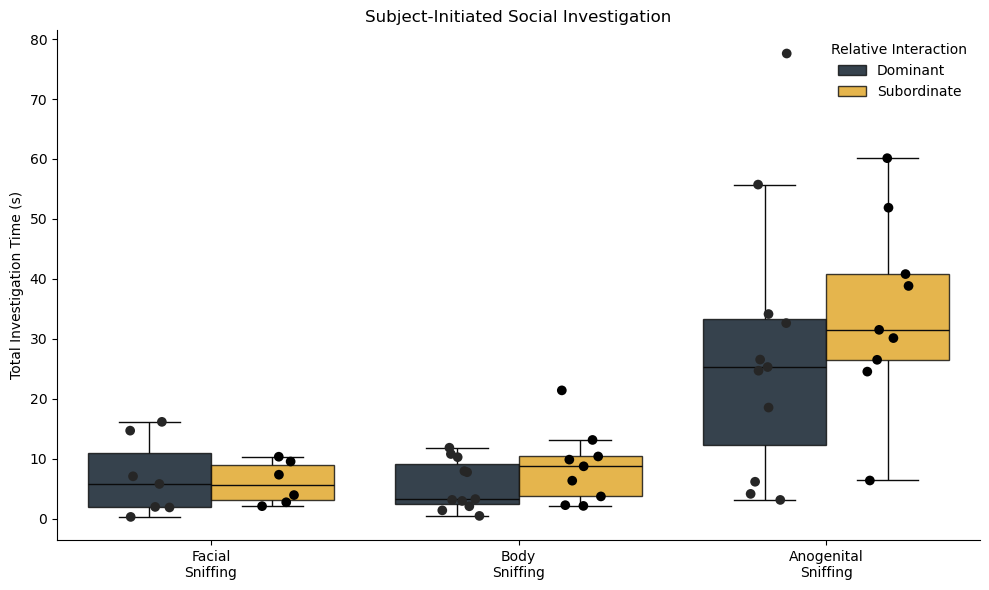

In [91]:
# ======================================================
# SUBJECT-INITIATED SOCIAL INVESTIGATION
# ======================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Padilla lab colors
blue = "#001424"      # DOM
mustard = "#ffaf00"   # SUB

palette = {
    "DOM": blue,
    "SUB": mustard
}

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Boxplots
sns.boxplot(
    data=plot_df,
    x="Behavior",
    y="InteractionDuration",
    hue="RelativeInteraction",
    palette=palette,
    showfliers=False,
    ax=ax
)

# Make boxes semi-transparent
for patch in ax.patches:
    patch.set_alpha(.8)

# Individual mice
sns.stripplot(
    data=plot_df,
    x="Behavior",
    y="InteractionDuration",
    hue="RelativeInteraction",
    dodge=True,
    color="black",
    size=7,
    alpha=1,
    jitter=0.15,
    ax=ax
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles[:2],
    ["Dominant", "Subordinate"],
    title="Relative Interaction",
    frameon=False
)

ax.set_ylabel(
    "Total Investigation Time (s)"
)

ax.set_xlabel("")

ax.set_title(
    "Subject-Initiated Social Investigation"
)

ax.set_xticklabels([
    "Facial\nSniffing",
    "Body\nSniffing",
    "Anogenital\nSniffing"
])

sns.despine()

plt.tight_layout()

plt.show()

In [92]:
# ======================================================
# DIGGING
# ======================================================

digging_df = (
    master_df[
        (master_df["Behavior"] == "digging")
        &
        (master_df["Subject"] == "subject")
    ]
    .groupby(
        [
            "SubjectID",
            "RelativeInteraction"
        ]
    )["InteractionDuration"]
    .sum()
    .reset_index()
)

print(digging_df.shape)
display(digging_df.head())

(16, 3)


,SubjectID,RelativeInteraction,InteractionDuration
0,1_1,DOM,59.267
1,1_1,SUB,165.271
2,1_2,DOM,0.833
3,1_3,SUB,112.333
4,2_1,DOM,139.954


C:\Users\sjs93\AppData\Local\Temp\ipykernel_18144\944975151.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


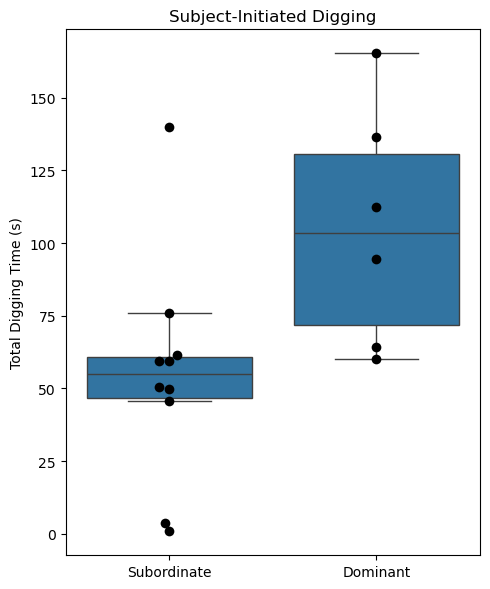

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(
    figsize=(5,6)
)

sns.boxplot(
    data=digging_df,
    x="RelativeInteraction",
    y="InteractionDuration",
    showfliers=False,
    ax=ax
)

sns.swarmplot(
    data=digging_df,
    x="RelativeInteraction",
    y="InteractionDuration",
    color="black",
    size=7,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Total Digging Time (s)")
ax.set_title("Subject-Initiated Digging")

ax.set_xticklabels(
    ["Subordinate", "Dominant"]
)

plt.tight_layout()
plt.show()

In [94]:
plot_df.groupby(
    ["Behavior", "RelativeInteraction"]
).size()

Behavior             RelativeInteraction
anogenital sniffing  DOM                     7
                     SUB                     6
body sniffing        DOM                    11
                     SUB                     9
facial sniffing      DOM                    11
                     SUB                     9
dtype: int64

In [96]:
master_df.groupby(
    ["Subject", "Behavior"]
)["InteractionDuration"].sum()

Subject       Behavior           
social_agent  allogrooming              0.958
              anogenital sniffing     178.299
              body sniffing           306.131
              digging                2349.067
              facial sniffing         762.066
              self-grooming            48.962
subject       anogenital sniffing      83.740
              body sniffing           139.721
              digging                1180.191
              facial sniffing         619.189
              self-grooming           150.588
Name: InteractionDuration, dtype: float64

In [97]:
master_df.columns

Index(['Observation id', 'Observation date', 'Description', 'Observation type',
       'Source', 'Time offset (s)', 'Coding duration', 'Media duration (s)',
       'FPS (frame/s)', 'Subject',
       'Observation duration by subject by observation', 'Behavior',
       'Behavioral category', 'Behavior type', 'Start (s)', 'Stop (s)',
       'Duration (s)', 'Media file name', 'Image index start',
       'Image index stop', 'Image file path start', 'Image file path stop',
       'Comment start', 'Comment stop', 'RecordingKey', 'SubjectID',
       'SocialAgentID', 'SubjectRank', 'SocialAgentRank',
       'RelativeInteraction', 'InteractionDuration', 'Media file',
       'Total length', 'FPS', 'Modifiers'],
      dtype='object')

In [98]:
print(df.columns.tolist())

['Observation id', 'Observation date', 'Description', 'Observation type', 'Source', 'Time offset (s)', 'Coding duration', 'Media duration (s)', 'FPS (frame/s)', 'Subject', 'Observation duration by subject by observation', 'Behavior', 'Behavioral category', 'Behavior type', 'Start (s)', 'Stop (s)', 'Duration (s)', 'Media file name', 'Image index start', 'Image index stop', 'Image file path start', 'Image file path stop', 'Comment start', 'Comment stop']


In [100]:
print(df[['Subject','Behavior','Start (s)','Stop (s)','Image index start','Image index stop']].head(10).to_string())

        Subject         Behavior  Start (s)  Stop (s)  Image index start  Image index stop
0  social_agent          digging     11.750    14.083                282               339
1  social_agent          digging     15.792    20.583                379               494
2  social_agent          digging     23.625    26.583                567               638
3       subject  facial sniffing     26.500    27.667                636               664
4  social_agent  facial sniffing     26.917    28.500                646               684
5  social_agent          digging     29.583    30.833                710               740
6  social_agent          digging     32.083    36.333                770               872
7       subject  facial sniffing     36.542    37.333                877               896
8  social_agent  facial sniffing     36.750    37.375                882               897
9       subject    body sniffing     38.583    39.125                926               939

In [101]:
print(df["Subject"].unique())

print(df["Behavior"].unique())

['social_agent' 'subject']
['digging' 'facial sniffing' 'body sniffing']


In [102]:
# ======================================================
# PROCESS ONE BORIS FILE
# FULL METADATA VERSION
# ======================================================

import re

beh_df = df.copy()

# ------------------------------------------------------
# parse filename
# ------------------------------------------------------

filename = boris_files[5]

print(filename)

match = re.search(
    r'(\d+)_(\d+)_2_([dis])_cm_(\d+)_(\d+)_([dis])',
    filename
)

rank_map = {
    "d": "DOM",
    "i": "INT",
    "s": "SUB"
}

# ------------------------------------------------------
# parse filename
# ------------------------------------------------------

match = re.search(
    r'(\d+)_(\d+)_(\d+)_([dis])_cm_(\d+)_(\d+)_([dis])',
    filename
)

# ------------------------------------------------------
# IDs
# ------------------------------------------------------

subject_id = (
    f"{match.group(1)}_{match.group(2)}"
)

social_agent_id = (
    f"{match.group(5)}_{match.group(6)}"
)

# ------------------------------------------------------
# cohort
# ------------------------------------------------------

cohort = match.group(3)

# ------------------------------------------------------
# ranks
# ------------------------------------------------------

subject_rank = rank_map[
    match.group(4)
]

social_agent_rank = rank_map[
    match.group(7)
]

# ------------------------------------------------------
# keep only social sniffing
# ------------------------------------------------------

social_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]

beh_df = beh_df[
    beh_df["Behavior"].isin(
        social_behaviors
    )
].copy()

# ------------------------------------------------------
# duration
# ------------------------------------------------------

beh_df["InteractionDuration"] = (
    beh_df["Stop (s)"]
    -
    beh_df["Start (s)"]
)

# ------------------------------------------------------
# metadata columns
# ------------------------------------------------------

beh_df["SubjectID"] = subject_id

beh_df["SocialAgentID"] = (
    social_agent_id
)

beh_df["Cohort"] = cohort

beh_df["SubjectRank"] = (
    subject_rank
)

beh_df["SocialAgentRank"] = (
    social_agent_rank
)

# ------------------------------------------------------
# subject-relative interaction label
# ------------------------------------------------------

rank_order = {
    "SUB": 0,
    "INT": 1,
    "DOM": 2
}

if rank_order[subject_rank] > rank_order[social_agent_rank]:

    relative_label = "DOM"

elif rank_order[subject_rank] < rank_order[social_agent_rank]:

    relative_label = "SUB"

else:

    relative_label = "EQUAL"

beh_df["RelativeInteraction"] = (
    relative_label
)

# ------------------------------------------------------
# rename actor column
# ------------------------------------------------------

beh_df = beh_df.rename(
    columns={
        "Subject": "Actor"
    }
)

# ------------------------------------------------------
# preview
# ------------------------------------------------------

display(

    beh_df[[
        "Actor",
        "Behavior",
        "InteractionDuration",
        "SubjectID",
        "SocialAgentID",
        "Cohort",
        "SubjectRank",
        "SocialAgentRank",
        "RelativeInteraction"
    ]].head(20)

)

1_3_2_s_1_2_d_20260107_165340.1_boris_AJ_with_image_indices_with_image_indices.csv


AttributeError: 'NoneType' object has no attribute 'group'

In [103]:
beh_df

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
0,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,social_agent,97.169,digging,Not defined,STATE,11.750,14.083,2.333,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,282,339,NaN,NaN,NaN,NaN
1,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,social_agent,97.169,digging,Not defined,STATE,15.792,20.583,4.791,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,379,494,NaN,NaN,NaN,NaN
2,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,social_agent,97.169,digging,Not defined,STATE,23.625,26.583,2.958,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,567,638,NaN,NaN,NaN,NaN
3,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,subject,40.499,facial sniffing,Not defined,STATE,26.500,27.667,1.167,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,636,664,NaN,NaN,NaN,NaN
4,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,social_agent,97.169,facial sniffing,Not defined,STATE,26.917,28.500,1.583,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,646,684,NaN,NaN,NaN,NaN
5,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,social_agent,97.169,digging,Not defined,STATE,29.583,30.833,1.250,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,710,740,NaN,NaN,NaN,NaN
6,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,social_agent,97.169,digging,Not defined,STATE,32.083,36.333,4.250,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,770,872,NaN,NaN,NaN,NaN
7,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,subject,40.499,facial sniffing,Not defined,STATE,36.542,37.333,0.791,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,877,896,NaN,NaN,NaN,NaN
8,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,social_agent,97.169,facial sniffing,Not defined,STATE,36.750,37.375,0.625,C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,882,897,NaN,NaN,NaN,NaN
9,8_2_s_cm_8_1_d_20260106_113241.1.mp4,2026-04-28 13:09:47.363,NaN,Media file,player #1:C:/Users/simmo/OneDrive/Desktop/boris mp4 csv/8_2_s_cm_8_1_d_20260106_113241.1.mp4,0.0,371.25,383.125,24.0,subject,40.499,body sniffing,Not defined,STATE,38.583,39.125,0.542,C:/Users/simmo/OneD

In [104]:
# ======================================================
# COHORT 1 PARSER
# ======================================================

import glob
import os
import re
import pandas as pd

cohort1_dir = (
    r"C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs"
)

cohort1_files = glob.glob(
    os.path.join(cohort1_dir, "*.h5")
)

rows = []

for path in cohort1_files:

    fname = os.path.basename(path)

    # remove extension
    stem = fname.replace(".h5", "")

    # Example:
    # CM_s1_1_d1_2_20250623_111352_merged

    # or:
    # CM_s1_2_sub1_1_20250623_133932_merged

    match = re.search(
        r'CM_s(\d+)_(\d+)_(d|sub)(\d+)_(\d+)',
        stem
    )

    if match is None:

        print("FAILED:", fname)
        continue

    # --------------------------------------------------
    # IDs
    # --------------------------------------------------

    subject_id = (
        f"{match.group(1)}_{match.group(2)}"
    )

    social_agent_id = (
        f"{match.group(4)}_{match.group(5)}"
    )

    # --------------------------------------------------
    # rank
    # --------------------------------------------------

    relation = match.group(3)

    if relation == "d":

        subject_rank = "DOM"
        social_agent_rank = "SUB"

    elif relation == "sub":

        subject_rank = "SUB"
        social_agent_rank = "DOM"

    else:

        subject_rank = "UNKNOWN"
        social_agent_rank = "UNKNOWN"

    # --------------------------------------------------
    # relative interaction
    # --------------------------------------------------

    relative_interaction = (
        subject_rank
        + "-" +
        social_agent_rank
    )

    # --------------------------------------------------
    # row
    # --------------------------------------------------

    row = {

        "Cohort": "1",

        "SubjectID":
            subject_id,

        "SocialAgentID":
            social_agent_id,

        "SubjectRank":
            subject_rank,

        "SocialAgentRank":
            social_agent_rank,

        "RelativeInteraction":
            relative_interaction,

        "H5Path":
            path,

        "Filename":
            fname
    }

    rows.append(row)

# ======================================================
# DATAFRAME
# ======================================================

cohort1_meta = pd.DataFrame(rows)

print(cohort1_meta.shape)

display(cohort1_meta)

(9, 8)


,Cohort,SubjectID,SocialAgentID,SubjectRank,SocialAgentRank,RelativeInteraction,H5Path,Filename
0,1,1_1,1_2,DOM,SUB,DOM-SUB,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5,CM_s1_1_d1_2_20250623_111352_merged.h5
1,1,1_2,1_1,SUB,DOM,SUB-DOM,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5,CM_s1_2_sub1_1_20250623_133932_merged.h5
2,1,2_3,2_4,DOM,SUB,DOM-SUB,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5,CM_s2_3_d2_4_20250623_151153_merged.h5
3,1,2_4,2_3,SUB,DOM,SUB-DOM,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5,CM_s2_4_sub2_3_20250623_143348_merged.h5
4,1,3_5,3_6,DOM,SUB,DOM-SUB,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_160001_merged.h5,CM_s3_5_d3_6_20250623_160001_merged.h5
5,1,3_5,3_6,DOM,SUB,DOM-SUB,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5,CM_s3_5_d3_6_20250623_170708_merged.h5
6,1,3_6,3_5,SUB,DOM,SUB-DOM,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5,CM_s3_6_sub3_5_20250623_174348_merged.h5
7,1,4_7,4_8,DOM,SUB,DOM-SUB,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5,CM_s4_7_d4_8_20250623_193718_merged.h5
8,1,4_8,4_7,SUB,DOM,SUB-DOM,C:\Users\sjs93\UF Dropbox\Sequioa Smith\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\CM interactions\cm_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5,CM_s4_8_sub4_7_20250623_182649_merged.h5


In [105]:
with h5py.File(h5_path, "r") as f:
    print(list(f.keys()))

['analog', 'dio', 'resp_clean', 'time']


In [107]:
with h5py.File(h5_path, "r") as f:

    print("resp_clean contents:")
    
    for key in f["resp_clean"].keys():
        print(key)

resp_clean contents:
signal
time


In [108]:
with h5py.File(h5_path, "r") as f:

    print(
        f["resp_clean"]["signal"].shape
    )

    print(
        f["resp_clean"]["time"].shape
    )

    print(
        f["resp_clean"]["time"][:10]
    )

    print(
        f["resp_clean"]["time"][-10:]
    )

(61027,)
(61027,)
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]
[610.17 610.18 610.19 610.2  610.21 610.22 610.23 610.24 610.25 610.26]


In [109]:
event = master_df.iloc[0]

event_start = event["Start (s)"]

print(event["Behavior"])
print(event_start)

body sniffing
24.867


In [112]:
with h5py.File(h5_path, "r") as f:

    resp = f["resp_clean"]["signal"][:]
    time = f["resp_clean"]["time"][:]

In [113]:
event = master_df.iloc[0]

event_start = event["Start (s)"]
event_stop  = event["Stop (s)"]

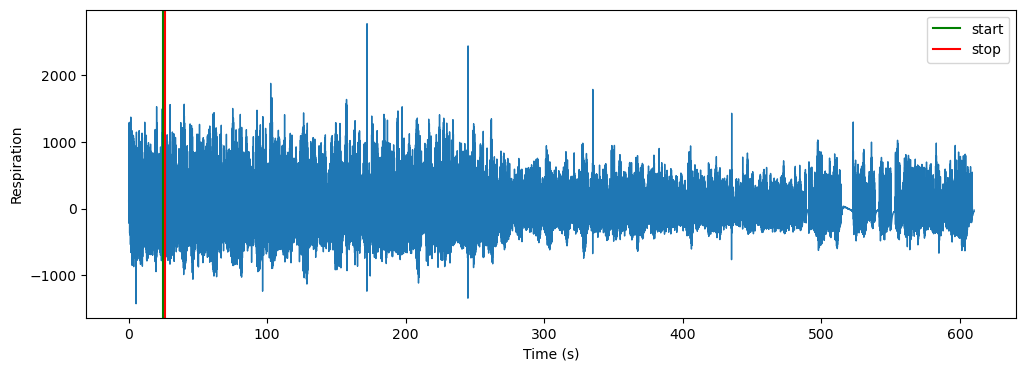

In [114]:
plt.figure(figsize=(12,4))

plt.plot(
    time,
    resp,
    linewidth=1
)

plt.axvline(
    event_start,
    color="green",
    label="start"
)

plt.axvline(
    event_stop,
    color="red",
    label="stop"
)

plt.legend()

plt.xlabel("Time (s)")
plt.ylabel("Respiration")

plt.show()

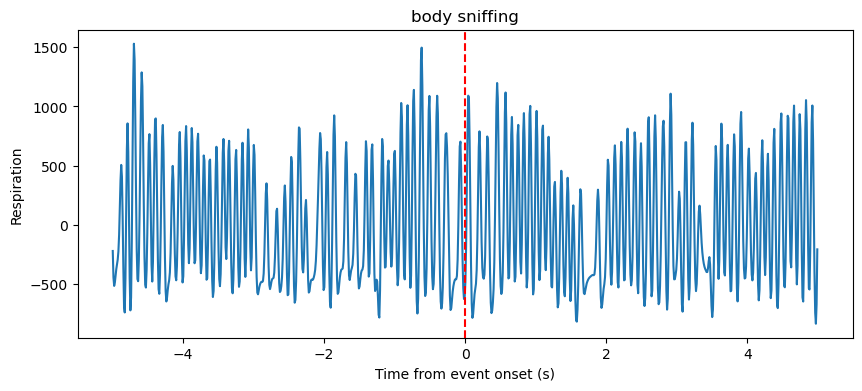

In [116]:
event = master_df.iloc[0]

event_start = event["Start (s)"]

window = (
    (time >= event_start - 5)
    &
    (time <= event_start + 5)
)

plt.figure(figsize=(10,4))

plt.plot(
    time[window] - event_start,
    resp[window]
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel(
    "Time from event onset (s)"
)

plt.ylabel(
    "Respiration"
)

plt.title(
    event["Behavior"]
)

plt.show()